#**Pre-request**

##Mount google drive


In [1]:
### **Mount** Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##Install pakages


In [2]:
#Install pakages
project_path = "/content/drive/MyDrive/Sem-6/coding/github/fraud_detection/"
!cat "{project_path}requirement/Install/NASEnhancedPretraindMLModleAdvance.txt"
!pip install  -r "{project_path}requirement/Install/NASEnhancedPretraindMLModleAdvance.txt" --no-cache-dir
%cd $project_path





torch
transformers
huggingface_hub
datasets
timm
patool
sktime
reformer_pytorch
optuna
ptflopsRequirement already satisfied: torch in /usr/local/lib/python3.12/dist-packages (from -r /content/drive/MyDrive/Sem-6/coding/github/fraud_detection/requirement/Install/NASEnhancedPretraindMLModleAdvance.txt (line 1)) (2.11.0+cu128)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.4/101.4 kB 304.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.5/37.5 MB 358.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 378.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 364.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.3/165.3 kB 352.0 MB/s eta 0:00:00
/content/drive/MyDrive/Sem-6/coding/github/fraud_detection


##Import  libs

In [3]:
# =====================================================
# ⏱️ Runtime & System Utilities
# =====================================================
import os
import sys
import time
import logging
import hashlib
import shutil
import subprocess
import warnings
from datetime import datetime
from argparse import Namespace

# Start timer
start_time = time.time()

# =====================================================
# 📦 Core Data Handling
# =====================================================
import numpy as np
import pandas as pd
import yaml

# Pandas display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

# =====================================================
# 📊 Visualization
# =====================================================
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================
# ⚙️ Machine Learning (Scikit-learn)
# =====================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, RobustScaler, StandardScaler
from sklearn.utils import class_weight
from sklearn.covariance import EmpiricalCovariance
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    cohen_kappa_score
)

# =====================================================
# 🌲 Gradient Boosting
# =====================================================
from xgboost import XGBClassifier
import joblib

# =====================================================
# 🔥 Deep Learning (PyTorch)
# =====================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torch.cuda.amp import autocast
from torch.utils.flop_counter import FlopCounterMode

# =====================================================
# 🧠 Deep Learning (TensorFlow / Keras)
# =====================================================
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Masking, Dropout, Layer
from tensorflow.keras.optimizers import Adam

# =====================================================
# 🤗 Transformers & Time Series
# =====================================================
from transformers import AutoModel
from sktime.datasets import load_from_tsfile_to_dataframe

# =====================================================
# 📈 Model Complexity / FLOPs
# =====================================================
from ptflops import get_model_complexity_info

# =====================================================
# 📊 Data Pipeline (Custom)
# =====================================================
sys.path.append('/content/drive/MyDrive/Sem-6/coding/github/fraud_detection/Time-Series-Library')

from models.TimesNet import Model as TimesNetModel
from data_provider.data_factory import data_provider

# =====================================================
# 🧠 Explainability
# =====================================================
import shap

# =====================================================
# 📊 Utilities & Progress
# =====================================================
from tqdm import tqdm

# =====================================================
# 📊 Google Colab (Optional)
# =====================================================
try:
    from google.colab import data_table
    data_table.enable_dataframe_formatter()
    data_table.DataTable.max_columns = 50
    data_table.DataTable.max_rows = 150
except ImportError:
    pass

# =====================================================
# ✅ Ready
# =====================================================
print("✅ All imports loaded successfully!")

✅ All imports loaded successfully!


##Confirmation setup

In [4]:
# =====================================================
# 🎲 Random Seeds (Reproducibility)
# =====================================================
!nvidia-smi                # confirm GPU
!pip show torch  # confirm versions
torch.manual_seed(123)
np.random.seed(123)

Sat Jul 11 07:59:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   34C    P0             52W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## Read Config file

In [5]:

logger = logging.getLogger(__name__)

def load_config(config_path="configs/baseline.yaml"):
    """Load YAML config file and expand ${root_path} placeholders."""
    with open(config_path, "r") as f:
        config = yaml.safe_load(f)

    logger.info(f"✅ Loaded config from {config_path}")

    # --- Expand ${root_path} placeholders ---
    root = config.get("root_path", "")

    def expand_paths(obj):
        if isinstance(obj, dict):
            return {k: expand_paths(v) for k, v in obj.items()}
        elif isinstance(obj, list):
            return [expand_paths(i) for i in obj]
        elif isinstance(obj, str) and "${root_path}" in obj:
            return obj.replace("${root_path}", root)
        else:
            return obj

    config = expand_paths(config)
    return config
config = load_config(os.path.join(project_path, "configs", "baseline.yaml"))


## Set Variables

In [6]:
max_seq_len = 6                  # Maximum sequence length
recent_mode = False               # False → oldest mode, True → recent-window mode
# n_jobs=-1
num_classes = 2                   # Binary classification
epochs = 20                       # Maximum training epochs

# ----------------------------------------------------------
# 📊 Evaluation Settings
# ----------------------------------------------------------
correlation_threshold = 0.85      # Feature correlation threshold

# ----------------------------------------------------------
# 📈 Progressive Evaluation
# ----------------------------------------------------------
method = "linear"                 # Interpolation method for key_rounds
n_points = 10                     # Number of evaluation points

# ----------------------------------------------------------
# 💾 Paths
# ----------------------------------------------------------
model_path = config['ML']['models']

# ==========================================================
# ✅ Configuration Summary
# ==========================================================
print("="*60)
print("📋 CONFIGURATION SUMMARY")
print("="*60)
print(f"  Sequence length:  {max_seq_len}")
print(f"  Mode:             {'Recent' if recent_mode else 'Oldest'}")
print(f"  Model path:       {model_path}")
print("="*60)

# Global unified results table for all models
results_table = pd.DataFrame(columns=["NAS SL", "Testing SL","Model","F1", "AUC", "Recall","Precision" ,"threshold","Round"])
summary = pd.DataFrame(
    columns=[
        "NAS SL",
        "Testing SL",
        "Model",
        "F1",
        "AUC",
        "Recall",
        "Precision",
        "threshold"
    ]
)


📋 CONFIGURATION SUMMARY
  Sequence length:  6
  Mode:             Oldest
  Model path:       /content/drive/MyDrive/Sem-6/coding/github/fraud_detection/models/


##Models Paramters

In [7]:
# ==================================================
# Base_SL = 6
# ==================================================

Base_SL = 'S6'

timesnet_parameters = {
    "learning_rate": 0.0017412281869383,
    "d_model":       32,
    "d_ff":          64,
    "e_layers":      5,
    "top_k":         2,
    "dropout":       0.3163853453695612,
    "batch_size":    8,
    "patience":      5,
    "num_kernels":   3,
}

lstm_parameters = {
    "learning_rate": 0.0027079530191957,
    "d_model":       16,
    "d_ff":          512,
    "e_layers":      3,
    "dropout":       0.2496096900772104,
    "batch_size":    8,
    "patience":      5,
}

transformer_parameters = {
    "learning_rate": 0.0004058163959568,
    "d_model":       32,
    "n_heads":       16,
    "d_ff":          256,
    "e_layers":      5,
    "dropout":       0.2929512364952867,
    "batch_size":    8,
    "patience":      5,
}

xgb_parameters = {
    "n_estimators":     118,
    "max_depth":        4,
    "learning_rate":    0.1050853224997026,
    "subsample":        0.7466340432319577,
    "colsample_bytree": 0.8407268330147646,
    "min_child_weight": 9,
    "gamma":            0.952125383012925,
    "patience":         2,
    "eval_metric":      "logloss",
}

rf_parameters = {
    "n_estimators":      184,
    "max_depth":         8,
    "min_samples_split": 19,
    "min_samples_leaf":  1,
}



In [8]:

# ✅ Unpack timesnet_parameters into simple variables for shell script
_tn_patience      = timesnet_parameters["patience"]
_tn_batch_size    = timesnet_parameters["batch_size"]
_tn_learning_rate = timesnet_parameters["learning_rate"]
_tn_e_layers      = timesnet_parameters["e_layers"]
_tn_d_model       = timesnet_parameters["d_model"]
_tn_d_ff          = timesnet_parameters["d_ff"]
_tn_top_k         = timesnet_parameters["top_k"]
_tn_dropout       = timesnet_parameters["dropout"]
_tn_num_kernels = timesnet_parameters["num_kernels"]


## Helpers

In [9]:
RESULTS_OUT = os.path.join(config["root_path"], "results", "Consolidated_v2")
os.makedirs(RESULTS_OUT, exist_ok=True)

def append_to_summary(summary, model_name, results):
    """
    Appends or updates the summary table with model results.
    Works with both capitalized and lowercase keys automatically.
    """
    # ✅ Create summary DataFrame if missing
    if summary is None or not isinstance(summary, pd.DataFrame):
          summary = pd.DataFrame(columns=["Model", "AUC", "Recall", "Precision", "F1", "Threshold"])
    # Ensure "Model" column exists (prevents KeyError)
    if "Model" not in summary.columns:
        summary = pd.DataFrame(columns=["Model", "AUC", "Recall", "Precision", "F1", "Threshold"])

    # ✅ Normalize key names to lowercase
    results = {k.lower(): v for k, v in results.items()}

    # ✅ Remove any existing row for the same model
    summary = summary[summary["Model"] != model_name]

    # ✅ Add new row (robust to missing values)
    row = {
        "NAS SL":Base_SL,
        "Testing SL": max_seq_len,
        "Model": model_name,
        "F1": round(results.get("f1", np.nan), 4) if not pd.isna(results.get("f1", np.nan)) else np.nan,
        "AUC": round(results.get("auc", np.nan), 4) if not pd.isna(results.get("auc", np.nan)) else np.nan,
        "Recall": round(results.get("recall", np.nan), 4) if not pd.isna(results.get("recall", np.nan)) else np.nan,
        "Precision": round(results.get("precision", np.nan), 4) if not pd.isna(results.get("precision", np.nan)) else np.nan,
        "Threshold": round(results.get("threshold", np.nan), 4) if not pd.isna(results.get("threshold", np.nan)) else np.nan
    }


    # ✅ Append and reindex
    summary = pd.concat([summary, pd.DataFrame([row])], ignore_index=True)
    summary = summary.reindex(columns=["NAS SL","Testing SL","Model","F1", "AUC", "Recall", "Precision",  "Threshold"])
    return summary

def plot_feature_importance(model, X_train, model_name="Model", top_n=20):
    """
    Plot feature importance for tree-based models (XGBoost, RandomForest).
    """


    # Handle model type
    if hasattr(model, "get_booster"):  # XGBoost
        importance = model.get_booster().get_score(importance_type='gain')
        fi = pd.DataFrame({
            'Feature': list(importance.keys()),
            'Importance': list(importance.values())
        })
    elif hasattr(model, "feature_importances_"):  # RandomForest
        fi = pd.DataFrame({
            'Feature': X_train.columns,
            'Importance': model.feature_importances_
        })
    else:
        raise ValueError(f"{model_name} does not support feature importance extraction.")

    # Sort and plot
    fi = fi.sort_values(by='Importance', ascending=False)
    display(fi.head(10))

    plt.figure(figsize=(10,6))
    plt.barh(fi['Feature'][:top_n][::-1], fi['Importance'][:top_n][::-1])
    plt.title(f'📊 {model_name} Feature Importance (Top {top_n})')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.grid(alpha=0.4)
    plt.tight_layout()
    plt.show()

    return fi




def find_best_threshold(y_true, probs, low=0.2, high=0.8, n=61):
    best_f1 = -1.0
    best_thr = 0.5
    for thr in np.linspace(low, high, n):
        preds = (probs >= thr).astype(int)
        f1 = f1_score(y_true, preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr
    return best_thr, best_f1


# ============================================================
# Second operating point: F2 (recall-weighted), validation-only
# ============================================================
from sklearn.metrics import fbeta_score

op2_table = pd.DataFrame(columns=[
    "Model", "Threshold_F1", "Threshold_F2", "Val_F2",
    "Test_F1_at_F2", "Test_Recall_at_F2", "Test_Precision_at_F2"])

def find_best_threshold_f2(y_true, probs, low=0.2, high=0.8, n=61, beta=2.0):
    best_fb, best_thr = -1.0, 0.5
    for thr in np.linspace(low, high, n):
        fb = fbeta_score(y_true, (probs >= thr).astype(int), beta=beta, zero_division=0)
        if fb > best_fb:
            best_fb, best_thr = fb, thr
    return best_thr, best_fb

def append_op2(op2_table, model_name, y_val, val_probs, y_test, test_probs, thr_f1):
    thr_f2, val_f2 = find_best_threshold_f2(y_val, val_probs)
    preds = (test_probs >= thr_f2).astype(int)
    row = {"Model": model_name, "Threshold_F1": round(thr_f1, 2),
           "Threshold_F2": round(thr_f2, 2), "Val_F2": round(val_f2, 4),
           "Test_F1_at_F2": round(f1_score(y_test, preds, zero_division=0), 4),
           "Test_Recall_at_F2": round(recall_score(y_test, preds, zero_division=0), 4),
           "Test_Precision_at_F2": round(precision_score(y_test, preds, zero_division=0), 4)}
    print(f"  🎯 {model_name}: thr_F1={thr_f1:.2f} → thr_F2={thr_f2:.2f} | "
          f"test recall {row['Test_Recall_at_F2']:.4f} / precision {row['Test_Precision_at_F2']:.4f}")
    return pd.concat([op2_table, pd.DataFrame([row])], ignore_index=True)

def plot_progressive_results(
    results_table,
    metrics=("AUC", "Recall", "F1"),
    round_col=None,
    figsize=(14, 6)
):
    """
    Plot progressive evaluation metrics per round for multiple models.

    Parameters
    ----------
    results_table : pd.DataFrame
        Must contain columns: Model, metrics, and either Round or input_size
    metrics : tuple
        Metrics to plot (default: AUC, Recall, F1)
    round_col : str or None
        Column name for x-axis. If None, auto-detects.
    figsize : tuple
        Figure size for plots
    """

    # --------------------------------------------------
    # Auto-detect round column
    # --------------------------------------------------
    if round_col is None:
        if "Round" in results_table.columns:
            round_col = "Round"
        elif "input_size" in results_table.columns:
            round_col = "input_size"
        else:
            raise ValueError("No Round or input_size column found.")

    # --------------------------------------------------
    # Sort results (important for correct curves)
    # --------------------------------------------------
    results_table = results_table.sort_values(
        by=[round_col, "Model"],
        ascending=True
    ).reset_index(drop=True)


    # --------------------------------------------------
    # Plot each metric
    # --------------------------------------------------
    for metric in metrics:

        plt.figure(figsize=figsize)

        for model in results_table["Model"].unique():
            subset = (
                results_table[results_table["Model"] == model]
                .sort_values(by=round_col)
            )

            plt.plot(
                subset[round_col],
                subset[metric],
                marker="o",
                markersize=6,
                linewidth=2,
                label=model,
                alpha=0.85
            )

        plt.title(f"{metric} per {round_col}", fontsize=18)
        plt.xlabel(round_col, fontsize=14)
        plt.ylabel(metric, fontsize=14)
        plt.grid(True, linestyle="--", alpha=0.4)

        # Legend outside
        plt.legend(
            loc="upper center",
            bbox_to_anchor=(0.5, -0.12),
            ncol=4,
            fontsize=10
        )

        plt.tight_layout(rect=[0, 0.1, 1, 1])
        plt.show()
    display(results_table)

    return results_table

# ============================================================
# 🔬 SCIENTIFIC KEY ROUNDS SELECTION
# ============================================================

def get_key_rounds(max_seq_len, method="linear", n_points=5):
    """
    Generate scientifically meaningful evaluation checkpoints.

    Args:
        max_seq_len: Maximum sequence length (16, 100, 300, etc.)
        method: Selection strategy
            - "linear": Equal spacing (1, 25%, 50%, 75%, 100%)
            - "logarithmic": More points early (where changes happen fast)
            - "sqrt": Square root spacing (balanced)
            - "percentile": Fixed percentages
        n_points: Number of evaluation points (default 5)

    Returns:
        List of round numbers to evaluate
    """

    if max_seq_len <= n_points:
        # If sequence is short, evaluate all rounds
        return list(range(1, max_seq_len + 1))

    if method == "linear":
        # Equal spacing: 1, 25%, 50%, 75%, 100%
        rounds = np.linspace(1, max_seq_len, n_points)

    elif method == "logarithmic":
        # More points early (fraud detection often shows early signal)
        # Log scale: 1, 2, 4, 8, 16 style
        rounds = np.logspace(0, np.log10(max_seq_len), n_points)

    elif method == "sqrt":
        # Square root spacing (balanced between linear and log)
        rounds = np.square(np.linspace(1, np.sqrt(max_seq_len), n_points))

    elif method == "percentile":
        # Fixed percentages: 1st event, 10%, 25%, 50%, 75%, 100%
        percentages = [0, 0.1, 0.25, 0.5, 0.75, 1.0]
        rounds = [max(1, int(p * max_seq_len)) for p in percentages]
        return sorted(set(rounds))  # Remove duplicates

    elif method == "early_focus":
        # Focus on early detection (more points in first half)
        # Useful for fraud detection where early signal matters
        early = np.linspace(1, max_seq_len * 0.5, n_points - 2)
        late = [max_seq_len * 0.75, max_seq_len]
        rounds = np.concatenate([early, late])

    else:
        raise ValueError(f"Unknown method: {method}")

    # Convert to integers, ensure valid range, remove duplicates
    rounds = [int(round(r)) for r in rounds]
    rounds = [max(1, min(r, max_seq_len)) for r in rounds]
    rounds = sorted(set(rounds))

    # Always include 1 and max_seq_len
    if 1 not in rounds:
        rounds = [1] + rounds
    if max_seq_len not in rounds:
        rounds = rounds + [max_seq_len]

    return rounds


# ============================================================
# General Metric + Gap Helpers
# ============================================================


def get_timesnet_val_threshold(results_dir):
    val_prob_path = os.path.join(results_dir, "val_prob.npy")
    val_true_path = os.path.join(results_dir, "val_true.npy")

    if not os.path.exists(val_prob_path) or not os.path.exists(val_true_path):
        raise FileNotFoundError(
            f"Missing validation probability files in {results_dir}. "
            f"Expected val_prob.npy and val_true.npy"
        )

    val_probs = np.load(val_prob_path)
    val_true = np.load(val_true_path)

    best_thr, best_f1 = find_best_threshold(val_true, val_probs)
    return best_thr, best_f1


gap_table = pd.DataFrame(columns=[
    "Model",
    "Train_F1", "Val_F1", "Test_F1",
    "Train_vs_Val_Gap",
    "Train_vs_Test_Gap",
    "Val_vs_Test_Gap",
    "Threshold"
])

def evaluate_probs(y_true, probs, threshold):
    preds = (probs >= threshold).astype(int)
    return {
        "F1": f1_score(y_true, preds, zero_division=0),
        "AUC": roc_auc_score(y_true, probs),
        "Recall": recall_score(y_true, preds, zero_division=0),
        "Precision": precision_score(y_true, preds, zero_division=0)
    }

def append_gap_result(gap_table, model_name, train_f1, val_f1, test_f1, threshold):
    row = {
        "Model": model_name,
        "Train_F1": round(train_f1, 4),
        "Val_F1": round(val_f1, 4),
        "Test_F1": round(test_f1, 4),
        "Train_vs_Val_Gap": round(train_f1 - val_f1, 4),
        "Train_vs_Test_Gap": round(train_f1 - test_f1, 4),
        "Val_vs_Test_Gap": round(val_f1 - test_f1, 4),
        "Threshold": round(threshold, 4)
    }

    gap_table = gap_table[gap_table["Model"] != model_name]
    gap_table = pd.concat([gap_table, pd.DataFrame([row])], ignore_index=True)
    return gap_table

def plot_probability_distribution(model_name, val_probs, test_probs, threshold, debug=True):
    val_probs = np.asarray(val_probs).flatten()
    test_probs = np.asarray(test_probs).flatten()

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.hist(val_probs, bins=50, alpha=0.7)
    plt.axvline(threshold, linestyle="--", label=f"Threshold={threshold:.2f}")
    plt.title(f"{model_name} Validation Probability")
    plt.xlabel("Fraud Probability")
    plt.ylabel("Frequency")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.hist(test_probs, bins=50, alpha=0.7)
    plt.axvline(threshold, linestyle="--", label=f"Threshold={threshold:.2f}")
    plt.title(f"{model_name} Test Probability")
    plt.xlabel("Fraud Probability")
    plt.ylabel("Frequency")
    plt.legend()

    plt.tight_layout()
    plt.show()

def print_detailed_report(model_name, y_true, y_pred):
    print("\n" + "="*60)
    print(f"📊 Detailed Report: {model_name}")
    print("="*60)
    print(classification_report(
        y_true,
        y_pred,
        target_names=["Normal", "Fraud"],
        digits=4,
        zero_division=0
    ))

## Drop and select features

In [10]:
# def prepare_features(df):
#     """
#     Selects only the explicitly defined features for model training.
#     You control which features are used by editing 'selected_features' below.
#     """

#     # --- Define selected features manually ---
#     selected_features = [
#         "window_size", "voc_total_calls", "voc_unique_contacts", "voc_total_duration",
#        "voc_avg_duration", "voc_max_duration", "voc_std_duration", "voc_active_days",
#        "voc_active_hours", "sms_total_msgs", "sms_unique_contacts", "sms_active_hours",
#        "sms_calltype_ratio", "app_months_active", "app_total_flow", "app_avg_flow",
#        "app_std_flow", "app_unique_apps_mean", "app_unique_apps_max", "user_months_active",
#         "arpu_mean", "arpu_std", "arpu_max", "idcard_cnt", "snapshot_round"
#    ]

#     # --- Keep only existing columns ---
#     available = [f for f in selected_features if f in df.columns]
#     missing = [f for f in selected_features if f not in df.columns]

#     X = df[available].copy()

#     #print(f"\n📊 Final features used ({len(available)}): {available}")
#     if missing:
#         print(f"⚠️ Missing columns not found in data: {missing}")

#     return X


## Key Rounds

In [11]:
# ============================================================
# 🔬 SCIENTIFIC KEY ROUNDS SELECTION
# ============================================================

key_rounds = get_key_rounds(max_seq_len, method=method, n_points=n_points)
print(f"📊 Evaluating rounds: {key_rounds}")
print(f"   Total: {len(key_rounds)} rounds instead of {max_seq_len}")

📊 Evaluating rounds: [1, 2, 3, 4, 5, 6]
   Total: 6 rounds instead of 6


#ML Modules

### Load

In [12]:
def load_raw_datasets(config):


    if "ML" in config and "Events" in config["ML"]:
        events_cfg = config["ML"]["Events"]
    else:
        events_cfg = config["Events"]

    base = events_cfg["base_path"]
    files = events_cfg["files"]

    # --- Load all datasets ---
    df_voc = pd.read_csv(os.path.join(base, files["voc"]))
    df_sms = pd.read_csv(os.path.join(base, files["sms"]))
    df_app = pd.read_csv(os.path.join(base, files["app"]))
    df_user = pd.read_csv(os.path.join(base, files["user"]))

    # --- Normalize timestamps and add source column ---
    for df, src in [(df_voc, "VOC"), (df_sms, "SMS"), (df_app, "APP"), (df_user, "USER")]:
        df["source"] = src
        ts_col = [c for c in df.columns if "time" in c.lower()][0]
        df.rename(columns={ts_col: "event_time"}, inplace=True)
        df["event_time"] = pd.to_datetime(df["event_time"], errors="coerce")

    print("✅ Raw datasets loaded and timestamp-normalized.")
    return df_voc, df_sms, df_app, df_user

df_voc, df_sms, df_app, df_user = load_raw_datasets(config)


✅ Raw datasets loaded and timestamp-normalized.


### Build timeline (events)

In [13]:
def merge_and_prepare_events(df_voc, df_sms, df_app, df_user):

    # --- 1️⃣ Normalize USER dataset ---
    if 'label' not in df_user.columns:
        raise KeyError("❌ 'label' column not found in user dataset")

    # Ensure numeric consistency
    df_user['label'] = df_user['label'].fillna(0).astype(int)
    df_user['idcard_cnt'] = df_user['idcard_cnt'].fillna(0).astype(float)
    df_user['arpu_value'] = df_user['arpu_value'].fillna(0).astype(float)

    # --- 2️⃣ Extract static info for merging (label + sim count only) ---
    #static_user_info = df_user.groupby("phone_no_m", as_index=False)[["label", "idcard_cnt"]].max()
    # --- 2️⃣ Extract static info from the RAW user table (covers all 6,106 users) ---
    lbl_cfg = config["ML"]["labels"]
    raw_user = pd.read_csv(os.path.join(lbl_cfg["base_path"], lbl_cfg["file"]))
    static_user_info = raw_user[["phone_no_m", "label", "idcard_cnt"]].drop_duplicates("phone_no_m")
    static_user_info["label"] = static_user_info["label"].astype(int)
    static_user_info["idcard_cnt"] = static_user_info["idcard_cnt"].fillna(0).astype(float)

    # --- 3️⃣ Merge static info into other event tables ---
    df_voc = df_voc.merge(static_user_info, on="phone_no_m", how="left")
    df_sms = df_sms.merge(static_user_info, on="phone_no_m", how="left")
    df_app = df_app.merge(static_user_info, on="phone_no_m", how="left")


    # --- 4️⃣ Combine all transactional event sources ---
    # include df_user itself since arpu_value is event-like
    events = pd.concat([df_voc, df_sms, df_app, df_user], ignore_index=True)

    # --- 5️⃣ Fill and order ---
    #events["label"] = events["label"].fillna(0).astype(int)
    missing = int(events["label"].isna().sum())
    assert missing == 0, f"{missing} events have no label — label merge is broken"
    events["label"] = events["label"].astype(int)

    events["event_time"] = pd.to_datetime(events["event_time"], errors="coerce")
    events = events.sort_values(["phone_no_m", "event_time"]).reset_index(drop=True)

    # --- 6️⃣ Summary ---
    print("\n🔎 Feature Summary per Source:")
    for src, df in [("VOC", df_voc), ("SMS", df_sms), ("APP", df_app), ("USER", df_user)]:
        print(f"\n📂 Source: {src}")
        print(f"   Events: {len(df):,}")
        print(f"   Users : {df['phone_no_m'].nunique():,}")
        print(f"   Columns ({len(df.columns)}): {', '.join(df.columns)}")

    print("\n📊 Combined Dataset Summary:")
    print(f"   Total events: {len(events):,}")
    print(f"   Unique users: {events['phone_no_m'].nunique():,}")
    print(f"   Fraud ratio: {events['label'].mean()*100:.2f}%")
    user_labels = events.groupby("phone_no_m")["label"].max()
    print(f"   Fraud users: {int(user_labels.sum()):,} / {user_labels.size:,} ({user_labels.mean()*100:.2f}%)")

    return events

events = merge_and_prepare_events(df_voc, df_sms, df_app, df_user)

display(events.head())


🔎 Feature Summary per Source:

📂 Source: VOC
   Events: 5,015,430
   Users : 6,025
   Columns (11): phone_no_m, opposite_no_m, calltype_id, event_time, call_dur, city_name, county_name, imei_m, source, label, idcard_cnt

📂 Source: SMS
   Events: 6,848,509
   Users : 6,103
   Columns (7): phone_no_m, opposite_no_m, calltype_id, event_time, source, label, idcard_cnt

📂 Source: APP
   Events: 3,283,602
   Users : 6,106
   Columns (10): phone_no_m, event_time, source, busi_name, flow, month_id, flow_norm, month_str, label, idcard_cnt

📂 Source: USER
   Events: 39,454
   Users : 5,929
   Columns (10): phone_no_m, event_time, source, month_id, arpu_value, city_name, county_name, idcard_cnt, label, month_col

📊 Combined Dataset Summary:
   Total events: 15,186,995
   Unique users: 6,106
   Fraud ratio: 24.63%
   Fraud users: 1,962 / 6,106 (32.13%)


,phone_no_m,opposite_no_m,calltype_id,event_time,call_dur,city_name,county_name,imei_m,source,label,idcard_cnt,busi_name,flow,month_id,flow_norm,month_str,arpu_value,month_col
0,00073ceecc0f7220a440580ac5dea410c90d14b6669458...,df22edbc0e3dd6bc4f2f453e687b743e8442a54834b64f...,2.0,2019-08-12 08:09:11,NaN,NaN,NaN,NaN,SMS,0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,00073ceecc0f7220a440580ac5dea410c90d14b6669458...,df22edbc0e3dd6bc4f2f453e687b743e8442a54834b64f...,2.0,2019-08-12 08:09:11,NaN,NaN,NaN,NaN,SMS,0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,00073ceecc0f7220a440580ac5dea410c90d14b6669458...,df22edbc0e3dd6bc4f2f453e687b743e8442a54834b64f...,2.0,2019-08-12 08:09:11,NaN,NaN,NaN,NaN,SMS,0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,00073ceecc0f7220a440580ac5dea410c90d14b6669458...,df22edbc0e3dd6bc4f2f453e687b743e8442a54834b64f...,2.0,2019-08-13 16:21:53,NaN,NaN,NaN,NaN,SMS,0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,00073ceecc0f7220a440580ac5dea410c90d14b6669458...,df22edbc0e3dd6bc4f2f453e687b743e8442a54834b64f...,2.0,2019-08-13 16:21:53,NaN,NaN,NaN,NaN,SMS,0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Split data based on users (fraud, not fraud)

In [14]:


# ======================================
# Clean Numeric Columns
# ======================================
events = events.copy()
numeric_cols = events.select_dtypes(include=["number"]).columns.difference(["label"])

# Replace NaN with 0 for numeric fields (avoids scaling issues)
events[numeric_cols] = events[numeric_cols].fillna(0)

print(f"\n📊 Numeric columns to scale ({len(numeric_cols)}): {numeric_cols.tolist()}")


# ======================================
# 2 Create / Load Shared Train-Val-Test User Split
# ======================================
split_dir = os.path.join(config["root_path"], "splits", "shared_user_split_v1")
train_split_file = f"{split_dir}/train_users.csv"
test_split_file  = f"{split_dir}/test_users.csv"
val_split_file   = f"{split_dir}/val_users.csv"

os.makedirs(split_dir, exist_ok=True)

all_split_files_exist = (
    os.path.exists(train_split_file)
    and os.path.exists(test_split_file)
    and os.path.exists(val_split_file)
)

if all_split_files_exist:
    print("📂 Using shared user split files...")
    train_users = set(pd.read_csv(train_split_file)["phone_no_m"])
    test_users  = set(pd.read_csv(test_split_file)["phone_no_m"])
    val_users   = set(pd.read_csv(val_split_file)["phone_no_m"])
else:
    print("🆕 Creating shared train/test/val user split...")

    # One label per user
    user_labels = events.groupby("phone_no_m")["label"].max()
    fraud_users = user_labels[user_labels == 1].index
    normal_users = user_labels[user_labels == 0].index

    # 1) Train/Test split (split fraud user %)
    fraud_train, fraud_test = train_test_split(
        fraud_users, test_size=0.2, random_state=42
    )
    normal_train, normal_test = train_test_split(
        normal_users, test_size=0.2, random_state=42
    )

    train_users_full = set(fraud_train) | set(normal_train)
    test_users = set(fraud_test) | set(normal_test)

    # 2) Validation split from training users only
    train_user_labels = user_labels.loc[list(train_users_full)]

    fraud_train_users = train_user_labels[train_user_labels == 1].index
    normal_train_users = train_user_labels[train_user_labels == 0].index

    fraud_tr, fraud_val = train_test_split(
        fraud_train_users, test_size=0.2, random_state=42
    )
    normal_tr, normal_val = train_test_split(
        normal_train_users, test_size=0.2, random_state=42
    )

    train_users = set(fraud_tr) | set(normal_tr)
    val_users   = set(fraud_val) | set(normal_val)

    pd.DataFrame({"phone_no_m": sorted(train_users)}).to_csv(train_split_file, index=False)
    pd.DataFrame({"phone_no_m": sorted(test_users)}).to_csv(test_split_file, index=False)
    pd.DataFrame({"phone_no_m": sorted(val_users)}).to_csv(val_split_file, index=False)

    print(f"✅ Saved shared split files to '{split_dir}/'")
# ======================================
# Split overlap checks
# ======================================
assert len(train_users & test_users) == 0, "❌ User leakage: train and test overlap"
assert len(train_users & val_users) == 0, "❌ User leakage: train and val overlap"
assert len(test_users & val_users) == 0, "❌ User leakage: test and val overlap"

print("🔒 Split overlap checks passed:")
print(f"   train ∩ test = {len(train_users & test_users)}")
print(f"   train ∩ val  = {len(train_users & val_users)}")
print(f"   test  ∩ val  = {len(test_users & val_users)}")
user_labels = events.groupby("phone_no_m")["label"].max()
print(f"   sizes  train/val/test = {len(train_users)} / {len(val_users)} / {len(test_users)}")
print(f"   fraud  train/val/test = {int(user_labels.loc[list(train_users)].sum())} / "
      f"{int(user_labels.loc[list(val_users)].sum())} / {int(user_labels.loc[list(test_users)].sum())}")
# ======================================
# Apply Split to Events
# ======================================
train_events = events[events["phone_no_m"].isin(train_users)]
test_events  = events[events["phone_no_m"].isin(test_users)]
val_events = events[events["phone_no_m"].isin(val_users)]

# Sanity checks
assert len(set(train_events["phone_no_m"]) & set(test_events["phone_no_m"])) == 0, "❌ User leakage detected!"
assert train_events["label"].nunique() == 2, "❌ Training set must contain both classes"
assert test_events["label"].nunique() == 2, "❌ Test set must contain both classes"


📊 Numeric columns to scale (6): ['arpu_value', 'call_dur', 'calltype_id', 'flow', 'flow_norm', 'idcard_cnt']
📂 Using shared user split files...
🔒 Split overlap checks passed:
   train ∩ test = 0
   train ∩ val  = 0
   test  ∩ val  = 0
   sizes  train/val/test = 3907 / 977 / 1222
   fraud  train/val/test = 1255 / 314 / 393


### Add hour

In [15]:

#for all 3 dataset
for name, df in [
    ('train_events', train_events),
    ('val_events', val_events),
    ('test_events', test_events)
]:
    df = df.copy()
    df['event_time'] = pd.to_datetime(df['event_time'])#Ensures time is in correct format
    df = df.sort_values(['phone_no_m', 'event_time'], kind='mergesort').reset_index(drop=True)#Each user's events are in chronological order
    df['dt_hours'] = df.groupby('phone_no_m')['event_time'].diff().dt.total_seconds() / 3600#Time gap between consecutive events per user and convert to hours
    df['dt_hours'] = df['dt_hours'].fillna(0)#First event has no previous event → set to 0
    df['dt_hours'] = np.log1p(df['dt_hours']) #Apply log transformation , Highly skewed (many small gaps, few very large gaps)

    #Saves processed version back
    if name == 'train_events':
        train_events = df
    elif name == 'val_events':
        val_events = df
    else:
        test_events = df

#copy event to be used for snapshot based orgianl events
train_events_unscaled = train_events.copy()
test_events_unscaled = test_events.copy()
val_events_unscaled = val_events.copy()




# ▶  Advance ML

### Scale for DL

In [16]:

#Scale
#scale_cols_seq = sorted(set(train_events.select_dtypes(include=["number"]).columns) - {"label"})
scale_cols_seq = sorted(set(train_events.select_dtypes(include=["number"]).columns) - {"label", "source_id"})
scaler_seq = StandardScaler().fit(train_events[scale_cols_seq])
#Training data only to be used for calc the scaler
train_events[scale_cols_seq] = scaler_seq.transform(train_events[scale_cols_seq])
test_events[scale_cols_seq]  = scaler_seq.transform(test_events[scale_cols_seq])
val_events[scale_cols_seq]   = scaler_seq.transform(val_events[scale_cols_seq])

# ======================================
# Create Sequences (using multiple features)
# ======================================
numeric_features = [c for c in numeric_cols if c not in ["label"]]  # exclude label

#add dt_hours
if 'dt_hours' in train_events.columns:
    numeric_features.append('dt_hours')

print(f"\n📦 Features used for sequences: {numeric_features}")
feature_cols_tf = numeric_features.copy()

#add source_id
if "source_id" not in feature_cols_tf:
    feature_cols_tf.append("source_id")

print("[Transformer] feature_cols_tf:", feature_cols_tf)


📦 Features used for sequences: ['arpu_value', 'call_dur', 'calltype_id', 'flow', 'flow_norm', 'idcard_cnt', 'dt_hours']
[Transformer] feature_cols_tf: ['arpu_value', 'call_dur', 'calltype_id', 'flow', 'flow_norm', 'idcard_cnt', 'dt_hours', 'source_id']


### make_user_sequences

In [17]:

# ============================================================
# 2️⃣ Selector functions (FIXED, SIMPLE)
# ============================================================

def selector_oldest(r):
    """Select oldest r events"""
    return lambda df_u: df_u.head(r)

# def selector_last_r(r):
#     """Select LAST r events (to match full evaluation behavior)"""
#     return lambda df_u: df_u.tail(r)

# def selector_most_recent(r):
#     """Select most recent r events (used AFTER window freeze)"""
#     return lambda df_u: df_u.tail(r)

def make_user_sequences(
    events,
    feature_cols=None,
    max_seq_len=100,
    event_selector=None,
):
    events = events.copy()
    users, X_seq, y = [], [], []

    # le = LabelEncoder()
    # events["source_id"] = le.fit_transform(events["source"].astype(str))
    SOURCE_MAP = {
        "APP": 0,
        "SMS": 1,
        "USER": 2,
        "VOC": 3,
    }

    unknown_sources = set(events["source"].astype(str).unique()) - set(SOURCE_MAP.keys())
    assert len(unknown_sources) == 0, f"❌ Unknown source values found: {unknown_sources}"

    events["source_id"] = events["source"].map(SOURCE_MAP).astype(int)

    if feature_cols is None:
        feature_cols = events.select_dtypes(include=["number"]) \
                             .columns.difference(["label"]) \
                             .tolist()
    if "source_id" not in feature_cols:
        feature_cols.append("source_id")

    for user, df_u in events.groupby("phone_no_m"):

        # 1️⃣ Sort
        df_u = df_u.sort_values("event_time")

        # 2️⃣ Freeze to last max_seq_len
        if recent_mode:
            df_u = df_u.tail(max_seq_len)   # E51..E100

        # 3️⃣ 🔁 APPLY PROGRESSIVE SELECTION HERE
        if event_selector is not None:
            df_u = event_selector(df_u)

        # 4️⃣ Features
        feats = df_u[feature_cols].to_numpy(dtype=float)

        # 5️⃣ Pad / truncate
        if len(feats) < max_seq_len:
            feats = np.pad(feats, ((max_seq_len - len(feats), 0), (0, 0)))
        else:
            feats = feats[-max_seq_len:]

        label = int(df_u["label"].max())

        X_seq.append(feats)
        y.append(label)
        users.append(user)

    return np.array(X_seq), np.array(y), np.array(users)



### Create sequences

In [18]:

trans_X_train, trans_y_train, users_train = make_user_sequences(train_events, feature_cols=numeric_features, max_seq_len=max_seq_len,event_selector=selector_oldest(max_seq_len))
trans_X_test, trans_y_test, users_test = make_user_sequences(test_events, feature_cols=numeric_features, max_seq_len=max_seq_len,event_selector=selector_oldest(max_seq_len))
trans_X_val, trans_y_val, _ =            make_user_sequences(val_events,    feature_cols=numeric_features,max_seq_len=max_seq_len, event_selector=selector_oldest(max_seq_len))
assert len(set(val_events["phone_no_m"])) > 0, "❌ Validation set is empty!"
assert val_events["label"].nunique() == 2, "❌ Validation set must contain both classes"

print("\n✅ Sequence Summary (per-user sequences):")
print(f"   X_train: {trans_X_train.shape} | Fraud ratio: {np.mean(trans_y_train)*100:.2f}%")
print(f"   X_test : {trans_X_test.shape} | Fraud ratio: {np.mean(trans_y_test)*100:.2f}%")

# ======================================
# Consistency Check
# ======================================
trans_rf_train = set(pd.read_csv(train_split_file)["phone_no_m"])
trans_rf_test  = set(pd.read_csv(test_split_file)["phone_no_m"])
assert trans_rf_train == train_users, "❌ Train user mismatch between LSTM and RF/XGB!"
assert trans_rf_test  == test_users,  "❌ Test user mismatch between LSTM and RF/XGB!"
print("\n🔒 Consistency Check: ✅ Same users used for all models (LSTM, RF, XGBoost).")



✅ Sequence Summary (per-user sequences):
   X_train: (3907, 6, 8) | Fraud ratio: 32.12%
   X_test : (1222, 6, 8) | Fraud ratio: 32.16%

🔒 Consistency Check: ✅ Same users used for all models (LSTM, RF, XGBoost).


### Correlation raw data

📊 Correlation Matrix — Raw Event Features (LSTM)


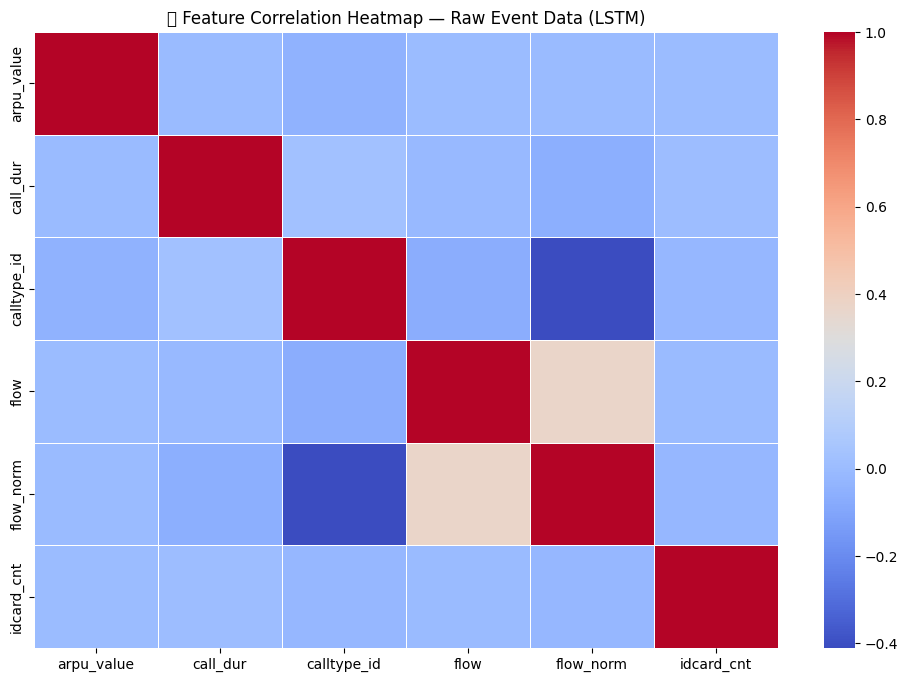

,Feature1,Feature2,Correlation


In [19]:
# --- LSTM correlation ---
print("📊 Correlation Matrix — Raw Event Features (LSTM)")

corr_lstm = pd.DataFrame(events[numeric_cols]).corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_lstm, cmap='coolwarm', annot=False, fmt=".2f", linewidths=0.5)
plt.title("📊 Feature Correlation Heatmap — Raw Event Data (LSTM)")
plt.show()

# Optional: Highly correlated pairs

corr_pairs_lstm = (
    corr_lstm.where(np.triu(np.ones(corr_lstm.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs_lstm.columns = ["Feature1", "Feature2", "Correlation"]
high_corr_lstm = corr_pairs_lstm[corr_pairs_lstm["Correlation"].abs() > correlation_threshold]
display(high_corr_lstm)


#Pretrained

#TimesNet

## Preparation

###Install

In [20]:


# ============================
# 1️⃣ Clean up any old copies only if you did not made any customzation to the code
# ============================
#!rm -rf /content/drive/MyDrive/Sem-6/coding/github/fraud_detection/Time-Series-Library

# ============================
# 2️⃣ Clone directly from gethub
# ============================
#!git clone https://github.com/thuml/Time-Series-Library.git /content/drive/MyDrive/Sem-6/coding/github/fraud_detection/Time-Series-Library

# ============================
# 3️⃣ Add repo to Python path
# ============================
import sys
sys.path.append('/content/drive/MyDrive/Sem-6/coding/github/fraud_detection/Time-Series-Library')

print("✅ Basic environment ready for TSLib!")

# ============================
# 4️⃣ Verify repo structure
# ============================
%cd /content/drive/MyDrive/Sem-6/coding/github/fraud_detection/Time-Series-Library
!ls -lh run.py

run_py = (
    "/content/drive/MyDrive/Sem-6/coding/github/fraud_detection/"
    "Time-Series-Library/run.py"
)
data_path= f"/content/drive/MyDrive/Sem-6/coding/github/fraud_detection/ExternalDataset/TimesNet/classification/FraudDataset_{max_seq_len}_{Base_SL}/"



✅ Basic environment ready for TSLib!
/content/drive/MyDrive/Sem-6/coding/github/fraud_detection/Time-Series-Library
-rw------- 1 root root 16K Jul 11 07:55 run.py


### Helper

In [21]:
def evaluate_experiment(
    results_dir: str,
    threshold,
    num_classes: int = None,
    class_labels=None,
    title: str = None,
    show_plot: bool = True,
):
    pred_path = os.path.join(results_dir, "pred.npy")
    true_path = os.path.join(results_dir, "true.npy")
    prob_path = os.path.join(results_dir, "prob.npy")

    if not os.path.exists(pred_path) or not os.path.exists(true_path):
        raise FileNotFoundError(f"❌ Could not find pred.npy or true.npy in {results_dir}")

    true = np.load(true_path).flatten()

    # ── Probabilities available → use passed validation threshold ──
    if os.path.exists(prob_path):
        probs = np.load(prob_path).flatten()

        try:
            auc_val = roc_auc_score(true, probs) if len(np.unique(true)) == 2 else np.nan
        except:
            auc_val = np.nan

        pred = (probs >= threshold).astype(int)
        best_thr = threshold

    # ── Fallback → hard labels only ──
    else:
        pred = np.load(pred_path).flatten()
        best_thr = 0.5
        try:
            auc_val = roc_auc_score(true, pred) if len(np.unique(true)) == 2 else np.nan
        except:
            auc_val = np.nan

    # ── Metrics from final pred ──
    acc  = accuracy_score(true, pred)
    prec = precision_score(true, pred, average="binary", zero_division=0)
    rec  = recall_score(true, pred, average="binary", zero_division=0)
    f1   = f1_score(true, pred, average="binary", zero_division=0)

    # ── Confusion matrix ──
    cm = confusion_matrix(true, pred)
    if class_labels is None:
        class_labels = [str(c) for c in np.unique(true)]

    # ── Plot ──
    if show_plot:
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
        plt.figure(figsize=(8, 8))
        disp.plot(cmap="Blues", values_format="d", colorbar=False)
        plt.title(title or f"Confusion Matrix ({os.path.basename(results_dir)})")
        plt.show()

    # ── Print ──
    print(f"\n📊 Accuracy: {acc:.4f}")
    print(f"📈 Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | AUC: {auc_val:.4f}")
    print(f"🎯 Threshold: {best_thr:.3f}")
    print("\nDetailed Report:")
    print(classification_report(true, pred, target_names=class_labels, digits=4))

    return {
        "NAS SL": Base_SL,
        "Testing SL": max_seq_len,
        "f1": f1,
        "accuracy": acc,
        "recall": rec,
        "precision": prec,
        "auc": auc_val,
        "confusion_matrix": cm,
        "threshold": round(best_thr, 3),
    }


#Covert data to ts format
def write_ts_file(
    X, y, split_name,
    problem_name="FraudDataset",
    out_dir=None,
    pad_to_dim=None,
    round_id=None
):


    if out_dir is None:
        out_dir = f"/content/drive/MyDrive/Sem-6/coding/github/fraud_detection/ExternalDataset/TimesNet/classification/FraudDataset_{max_seq_len}_{Base_SL}"
    os.makedirs(out_dir, exist_ok=True)
    suffix = f"_R{round_id}" if round_id is not None else ""
    ts_path = os.path.join(
        out_dir,
        f"{problem_name}_{split_name.upper()}{suffix}.ts"
    )


    with open(ts_path, "w") as f:
        f.write(f"@problemName {problem_name}\n")
        f.write("@timeStamps false\n")
        f.write("@univariate false\n")
        f.write("@classLabel true 0 1\n")
        f.write("@data\n")

        for i in range(len(X)):
            arr = np.array(X[i])

            # --- Pad or trim to target feature dimension ---
            if pad_to_dim is not None:
                if arr.ndim == 1:
                    arr = arr.reshape(-1, 1)
                n_dim = arr.shape[1]
                if n_dim < pad_to_dim:
                    pad = np.zeros((arr.shape[0], pad_to_dim - n_dim))
                    arr = np.hstack((arr, pad))
                elif n_dim > pad_to_dim:
                    arr = arr[:, :pad_to_dim]

            # --- Convert to string format ---
            if arr.ndim == 1:
                arr_str = ",".join(map(str, arr))
            else:
                parts = [",".join(map(str, arr[:, d])) for d in range(arr.shape[1])]
                arr_str = " : ".join(parts)  # colon separates dimensions

            f.write(f"{arr_str}:{int(y[i])}\n")

    print(f"✅ Wrote {ts_path} with {len(X)} samples (strict sktime format)")
    if pad_to_dim:
        print(f"📏 Feature dimensions padded/trimmed to {pad_to_dim}")


def get_timesnet_val_threshold(results_dir):
    """Finds best threshold on validation set """
    val_prob_path = os.path.join(results_dir, "val_prob.npy")
    val_true_path = os.path.join(results_dir, "val_true.npy")

    if not os.path.exists(val_prob_path):
        raise FileNotFoundError(f"Missing val_prob.npy in {results_dir}")

    val_probs = np.load(val_prob_path).flatten()
    val_true = np.load(val_true_path).flatten()

    best_f1, best_thr = -1.0, 0.5
    for thr in np.linspace(0.2, 0.8, 61):
        f1 = f1_score(val_true, (val_probs >= thr).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_thr = f1, thr
    return best_thr, best_f1

def plot_timesnet_diagnostics(probs, labels, threshold, title):
    """Generates Point 8 (U-Shape) and Point 10 (CM) graphs"""
    plt.figure(figsize=(12, 5))

    # Left: Probability Distribution
    plt.subplot(1, 2, 1)
    plt.hist(probs, bins=50, color='teal', alpha=0.7)
    plt.axvline(threshold, color='red', linestyle='--', label=f'Best Thr: {threshold:.2f}')
    plt.title(f"{title} - Prob Distribution  ")
    plt.xlabel("Fraud Probability")
    plt.legend()

    # Right: Confusion Matrix
    plt.subplot(1, 2, 2)
    cm = confusion_matrix(labels, (probs >= threshold).astype(int))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
    plt.title(f"{title} - Matrix")
    plt.show()

def append_timesnet_gap(gap_table, model_name, results_dir, threshold):
    train_prob_path = os.path.join(results_dir, "train_prob.npy")
    train_true_path = os.path.join(results_dir, "train_true.npy")

    val_prob_path = os.path.join(results_dir, "val_prob.npy")
    val_true_path = os.path.join(results_dir, "val_true.npy")

    test_prob_path = os.path.join(results_dir, "prob.npy")
    test_true_path = os.path.join(results_dir, "true.npy")

    if not all(os.path.exists(p) for p in [
        train_prob_path, train_true_path,
        val_prob_path, val_true_path,
        test_prob_path, test_true_path
    ]):
        print(f"⚠️ {model_name}: train/val/test probability files are not complete.")
        return gap_table

    train_probs = np.load(train_prob_path).flatten()
    train_true  = np.load(train_true_path).flatten()

    val_probs = np.load(val_prob_path).flatten()
    val_true  = np.load(val_true_path).flatten()

    test_probs = np.load(test_prob_path).flatten()
    test_true  = np.load(test_true_path).flatten()

    train_f1 = f1_score(train_true, (train_probs >= threshold).astype(int), zero_division=0)
    val_f1   = f1_score(val_true,   (val_probs   >= threshold).astype(int), zero_division=0)
    test_f1  = f1_score(test_true,  (test_probs  >= threshold).astype(int), zero_division=0)

    return append_gap_result(
        gap_table,
        model_name,
        train_f1,
        val_f1,
        test_f1,
        threshold
    )

def plot_timesnet_loss(results_dir, model_name):
    loss_path = os.path.join(results_dir, "loss_history.csv")

    if not os.path.exists(loss_path):
        print(f"⚠️ {model_name}: loss_history.csv not found.")
        return

    df_loss = pd.read_csv(loss_path)

    plt.figure(figsize=(8, 5))
    plt.plot(df_loss["epoch"], df_loss["train_loss"], label="Train Loss")
    plt.plot(df_loss["epoch"], df_loss["val_loss"], label="Val Loss")
    plt.plot(df_loss["epoch"], df_loss["test_loss"], label="Test Loss", linestyle="--")

    plt.title(f"{model_name} Loss Convergence")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    display(df_loss)


### Covert  data to ts format

In [22]:

write_ts_file(trans_X_train, trans_y_train, split_name="TRAIN", pad_to_dim=13)
write_ts_file(trans_X_test, trans_y_test, split_name="TEST", pad_to_dim=13)
write_ts_file(trans_X_val, trans_y_val, split_name="VAL", pad_to_dim=13)



✅ Wrote /content/drive/MyDrive/Sem-6/coding/github/fraud_detection/ExternalDataset/TimesNet/classification/FraudDataset_6_S6/FraudDataset_TRAIN.ts with 3907 samples (strict sktime format)
📏 Feature dimensions padded/trimmed to 13
✅ Wrote /content/drive/MyDrive/Sem-6/coding/github/fraud_detection/ExternalDataset/TimesNet/classification/FraudDataset_6_S6/FraudDataset_TEST.ts with 1222 samples (strict sktime format)
📏 Feature dimensions padded/trimmed to 13
✅ Wrote /content/drive/MyDrive/Sem-6/coding/github/fraud_detection/ExternalDataset/TimesNet/classification/FraudDataset_6_S6/FraudDataset_VAL.ts with 977 samples (strict sktime format)
📏 Feature dimensions padded/trimmed to 13


### Show sample and Summrize

In [23]:
file_path = f"/content/drive/MyDrive/Sem-6/coding/github/fraud_detection/ExternalDataset/TimesNet/classification/FraudDataset_{max_seq_len}_{Base_SL}/FraudDataset_TRAIN.ts"
X, y = load_from_tsfile_to_dataframe(file_path)

print("✅ Loaded OK!")
print(X.shape)
print(set(y))

#ts_dir = f"/content/drive/MyDrive/Sem-6/coding/github/fraud_detection/ExternalDataset/TimesNet/classification/FraudDataset_{max_seq_len}_{Base_SL}"

for fname in ["FraudDataset_TRAIN.ts", "FraudDataset_TEST.ts"]:
    fpath = os.path.join(data_path, fname)
    print(f" {fname}: exists = {os.path.exists(fpath)} | size = {os.path.getsize(fpath)/1024:.1f} KB")
    if os.path.exists(fpath):
        with open(fpath) as f:
            for i, line in enumerate(f):
                if i < 10:
                    print(line.strip())
                else:
                    break
        print("------\n")



X, y = load_from_tsfile_to_dataframe(file_path)

print("✅ File loaded successfully!")
print(f"Shape of X: {X.shape}")
print(f"Number of labels: {len(set(y))}")
print(f"Labels: {set(y)}")
#print(f"Example (first row):\n", X.iloc[0])

print("Feature ranges per column:")
for col in range(X.shape[1]):
    values = np.concatenate(X.iloc[:, col].values)
    print(f"Column {col}: mean={np.mean(values):.3f}, std={np.std(values):.3f}")


✅ Loaded OK!
(3907, 13)
{np.str_('1'), np.str_('0')}
 FraudDataset_TRAIN.ts: exists = True | size = 3934.7 KB
@problemName FraudDataset
@timeStamps false
@univariate false
@classLabel true 0 1
@data
-0.029840919093863435,-0.029840919093863435,-0.029840919093863435,-0.029840919093863435,-0.029840919093863435,-0.029840919093863435 : -0.23359317309003816,-0.23359317309003816,-0.23359317309003816,-0.23359317309003816,-0.23359317309003816,-0.23359317309003816 : 0.8381382030441827,0.8381382030441827,0.8381382030441827,0.8381382030441827,0.8381382030441827,0.8381382030441827 : -0.041480529072158906,-0.041480529072158906,-0.041480529072158906,-0.041480529072158906,-0.041480529072158906,-0.041480529072158906 : -0.2519196987865733,-0.2519196987865733,-0.2519196987865733,-0.2519196987865733,-0.2519196987865733,-0.2519196987865733 : -0.8170257391209248,-0.8170257391209248,-0.8170257391209248,-0.8170257391209248,-0.8170257391209248,-0.8170257391209248 : -0.5335819405272189,-0.5335819405272189,-0.53

### Model and training

###### Head Partial unfreeze ▶(classifier (head/fc/projection)

In [24]:

print(f"[{datetime.now()}] 🚀 Starting TimesNet PartialUnfreeze training...")

print("seq len", max_seq_len)
print("datapath", data_path)

# !CUDA_VISIBLE_DEVICES=0 \
# python -u /content/drive/MyDrive/Sem-6/coding/github/fraud_detection/Time-Series-Library/run.py \
#   --task_name classification \
#   --is_training 1 \
#   --mode PartialUnfreeze \
#   --root_path $data_path \
#   --model_id FraudDataset_PartialUnfreeze \
#   --model TimesNet \
#   --data UEA \
#   --data_path FraudDataset \
#   --features M \
#   --seq_len $max_seq_len \
#   --num_kernels $_tn_num_kernels \
#   --target OT \
#   --gpu 0 \
#   --use_gpu 1 \
#   --train_epochs $epochs \
#   --patience $_tn_patience \
#   --batch_size $_tn_batch_size \
#   --learning_rate $_tn_learning_rate \
#   --e_layers $_tn_e_layers \
#   --d_model $_tn_d_model \
#   --d_ff $_tn_d_ff \
#   --top_k $_tn_top_k \
#   --dropout $_tn_dropout \
#   --des PartialUnfreeze \
#   --itr 1

# print(f"[{datetime.now()}] ✅ TimesNet PartialUnfreeze training complete")

# # ==========================================================
# # ==========================================================
# print(f"[{datetime.now()}] 📊 Evaluating PartialUnfreeze...")

# results_dir = (
#     f"./test_results/"
#     f"classification_FraudDataset_PartialUnfreeze_"
#     f"TimesNet_UEA_ftM_"
#     f"sl{max_seq_len}_"
#     f"ll48_"
#     f"pl0_"
#     f"dm{timesnet_parameters['d_model']}_"
#     f"nh8_"
#     f"el{timesnet_parameters['e_layers']}_"
#     f"dl1_"
#     f"df{timesnet_parameters['d_ff']}_"
#     f"expand2_"
#     f"dc4_"
#     f"fc1_"
#     f"ebtimeF_"
#     f"dtTrue_"
#     f"PartialUnfreeze_0"
# )


[2026-07-11 08:03:23.482730] 🚀 Starting TimesNet PartialUnfreeze training...
seq len 6
datapath /content/drive/MyDrive/Sem-6/coding/github/fraud_detection/ExternalDataset/TimesNet/classification/FraudDataset_6_S6/


In [25]:

# print(f"[DEBUG] Using path: {results_dir}")
# best_thr_tn, best_f1_tn_val = get_timesnet_val_threshold(results_dir)
# print(f"  ✅ TimesNet_PartialUnfreeze validation threshold: {best_thr_tn:.2f} | val_f1={best_f1_tn_val:.4f}")

# results_partial = evaluate_experiment(
#     results_dir,
#     threshold=best_thr_tn,
#     num_classes=2,
#     title="PartialUnfreeze"
# )

# summary = append_to_summary(summary, "TimesNet_PartialUnfreeze", results_partial)


# gap_table = append_timesnet_gap(
#     gap_table,
#     "TimesNet_PartialUnfreeze",
#     results_dir,
#     best_thr_tn
# )
# tn_val_probs = np.load(os.path.join(results_dir, "val_prob.npy")).flatten()
# tn_test_probs = np.load(os.path.join(results_dir, "prob.npy")).flatten()
# tn_val_true = np.load(os.path.join(results_dir, "val_true.npy")).flatten()
# tn_test_true = np.load(os.path.join(results_dir, "true.npy")).flatten()
# op2_table = append_op2(op2_table, "TimesNet_PartialUnfreeze", tn_val_true, tn_val_probs, tn_test_true, tn_test_probs, best_thr_tn)

# plot_probability_distribution(
#     "TimesNet_PartialUnfreeze",
#     tn_val_probs,
#     tn_test_probs,
#     best_thr_tn
# )
# plot_timesnet_loss(
#     results_dir,
#     "TimesNet_PartialUnfreeze"
# )
# display(summary)
# display(gap_table.sort_values("Model").reset_index(drop=True))


##### Full training

In [26]:

print(f"[{datetime.now()}] 🚀 Starting TimesNet Unfreeze training...")

!CUDA_VISIBLE_DEVICES=0 \
python -u /content/drive/MyDrive/Sem-6/coding/github/fraud_detection/Time-Series-Library/run.py \
  --task_name classification \
  --is_training 1 \
  --mode UnfrozenOptWL \
  --root_path $data_path \
  --model_id FraudDataset_Unfrozen \
  --model TimesNet \
  --data UEA \
  --data_path FraudDataset \
  --features M \
  --seq_len $max_seq_len \
  --num_kernels $_tn_num_kernels \
  --target OT \
  --gpu 0 \
  --use_gpu 1 \
  --train_epochs $epochs \
  --patience $_tn_patience \
  --batch_size $_tn_batch_size \
  --learning_rate $_tn_learning_rate \
  --e_layers $_tn_e_layers \
  --d_model $_tn_d_model \
  --d_ff $_tn_d_ff \
  --top_k $_tn_top_k \
  --dropout $_tn_dropout \
  --des UnfrozenOptWL \
  --seed 123 \
  --itr 1 \
  #--num_workers 1

print(f"[{datetime.now()}]  TimesNet Unfreeze training complete")


[2026-07-11 08:03:23.493337] 🚀 Starting TimesNet Unfreeze training...
Using GPU
Use UnfrozenOptWL
Use GPU: cuda:0
🔧 Building model and loading metadata...

========== Experiment Arguments ==========
activation               : gelu
alpha                    : 0.1
anomaly_ratio            : 0.25
augmentation_ratio       : 0
batch_size               : 8
c_out                    : 7
channel_independence     : 1
checkpoints              : ./checkpoints/
conv_channel             : 32
d_conv                   : 4
d_ff                     : 64
d_layers                 : 1
d_model                  : 32
data                     : UEA
data_path                : FraudDataset
dec_in                   : 7
decomp_method            : moving_avg
des                      : UnfrozenOptWL
device                   : cuda:0
devices                  : 0,1,2,3
discdtw                  : False
discsdtw                 : False
distil                   : True
down_sampling_layers     : 0
down_sampling_method     

[DEBUG] Using path: ./test_results/classification_FraudDataset_Unfrozen_TimesNet_UEA_ftM_sl6_ll48_pl0_dm32_nh8_el5_dl1_df64_expand2_dc4_fc1_ebtimeF_dtTrue_UnfrozenOptWL_0
  ✅ TimesNet_Unfrozen validation threshold: 0.36 | val_f1=0.6874


<Figure size 800x800 with 0 Axes>

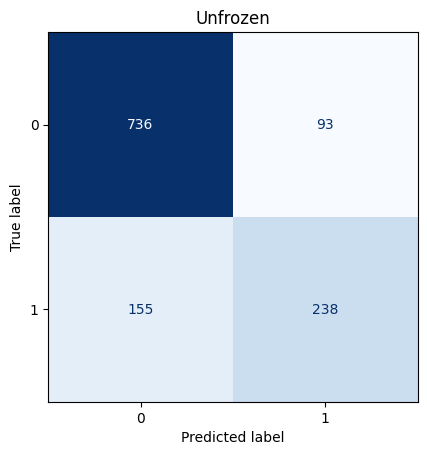


📊 Accuracy: 0.7971
📈 Precision: 0.7190 | Recall: 0.6056 | F1: 0.6575 | AUC: 0.8328
🎯 Threshold: 0.360

Detailed Report:
              precision    recall  f1-score   support

           0     0.8260    0.8878    0.8558       829
           1     0.7190    0.6056    0.6575       393

    accuracy                         0.7971      1222
   macro avg     0.7725    0.7467    0.7566      1222
weighted avg     0.7916    0.7971    0.7920      1222

  🎯 TimesNet_Unfrozen: thr_F1=0.36 → thr_F2=0.20 | test recall 0.6947 / precision 0.6691


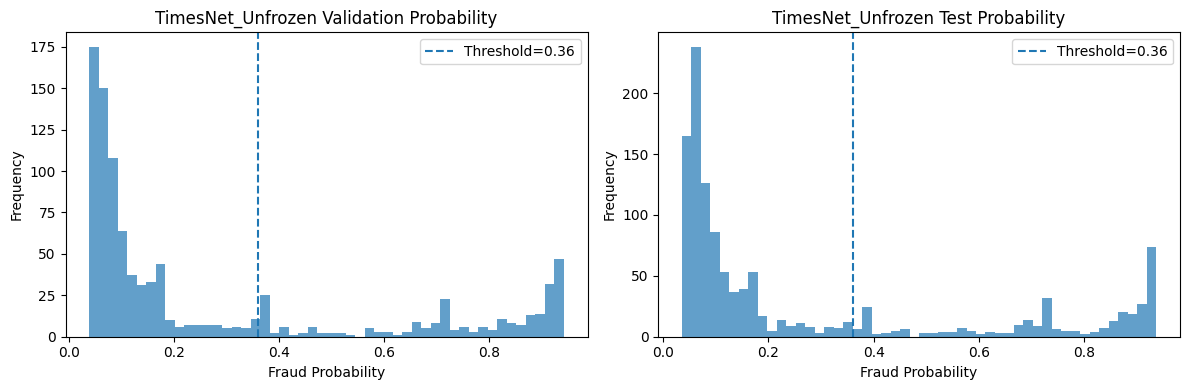

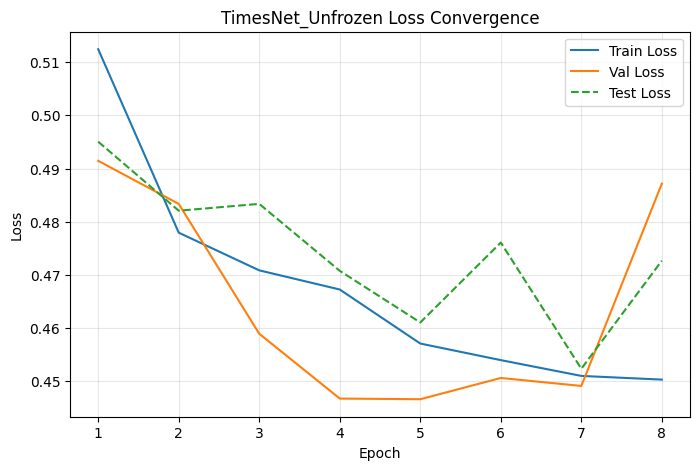

,epoch,time_sec,train_loss,val_loss,val_f1,test_loss,test_f1
0,1,22.074062,0.512432,0.491445,0.677266,0.495041,0.687023
1,2,18.711198,0.477937,0.483345,0.674304,0.482067,0.668374
2,3,18.671512,0.470852,0.458931,0.687392,0.483350,0.684478
3,4,18.536108,0.467247,0.446740,0.685805,0.470757,0.675676
4,5,18.446546,0.457088,0.446618,0.684211,0.461048,0.677223
5,6,18.839123,0.453970,0.450612,0.685714,0.476075,0.676960
6,7,18.663426,0.451003,0.449117,0.676647,0.452350,0.694872
7,8,18.711215,0.450307,0.487150,0.685524,0.472671,0.694444


,NAS SL,Testing SL,Model,F1,AUC,Recall,Precision,Threshold
0,S6,6,TimesNet_Unfrozen,0.6575,0.8328,0.6056,0.719,0.36


,Model,Train_F1,Val_F1,Test_F1,Train_vs_Val_Gap,Train_vs_Test_Gap,Val_vs_Test_Gap,Threshold
0,TimesNet_Unfrozen,0.674,0.6874,0.6575,-0.0134,0.0165,0.0299,0.36


In [27]:

# ==========================================================
# EVALUATE NAS BEST (Unfrozen mode)
# ==========================================================

results_dir_unfrozen = (
    f"./test_results/"
    f"classification_FraudDataset_Unfrozen_"
    f"TimesNet_UEA_ftM_"
    f"sl{max_seq_len}_"
    f"ll48_"
    f"pl0_"
    f"dm{timesnet_parameters['d_model']}_"
    f"nh8_"
    f"el{timesnet_parameters['e_layers']}_"
    f"dl1_"
    #f"df64_"
    f"df{timesnet_parameters['d_ff']}_"
    f"expand2_"
    f"dc4_"
    f"fc1_"
    f"ebtimeF_"
    f"dtTrue_"
    f"UnfrozenOptWL_0"
)


print(f"[DEBUG] Using path: {results_dir_unfrozen}")


best_thr_tn_unfrozen, best_f1_tn_val_unfrozen = get_timesnet_val_threshold(results_dir_unfrozen)
print(f"  ✅ TimesNet_Unfrozen validation threshold: {best_thr_tn_unfrozen:.2f} | val_f1={best_f1_tn_val_unfrozen:.4f}")

results_unfrozen = evaluate_experiment(
    results_dir_unfrozen,
    threshold=best_thr_tn_unfrozen,
    num_classes=2,
    title="Unfrozen"
)

gap_table = append_timesnet_gap(
    gap_table,
    "TimesNet_Unfrozen",
    results_dir_unfrozen,
    best_thr_tn_unfrozen
)
tn_val_probs = np.load(os.path.join(results_dir_unfrozen, "val_prob.npy")).flatten()
tn_test_probs = np.load(os.path.join(results_dir_unfrozen, "prob.npy")).flatten()
tn_val_true = np.load(os.path.join(results_dir_unfrozen, "val_true.npy")).flatten()
tn_test_true = np.load(os.path.join(results_dir_unfrozen, "true.npy")).flatten()
op2_table = append_op2(op2_table, "TimesNet_Unfrozen", tn_val_true, tn_val_probs, tn_test_true, tn_test_probs, best_thr_tn_unfrozen)


plot_probability_distribution(
    "TimesNet_Unfrozen",
    tn_val_probs,
    tn_test_probs,
    best_thr_tn_unfrozen
)
plot_timesnet_loss(
    results_dir_unfrozen,
    "TimesNet_Unfrozen"
)
summary = append_to_summary(summary, "TimesNet_Unfrozen", results_unfrozen)
display(summary)
display(gap_table.sort_values("Model").reset_index(drop=True))


##### Gradually for both

In [28]:


# def md5(path):
#     with open(path, "rb") as f:
#         return hashlib.md5(f.read()).hexdigest()


# def find_latest_results_dir(base="./test_results"):
#     if not os.path.exists(base):
#         raise RuntimeError("❌ test_results directory does not exist")

#     candidates = [
#         os.path.join(base, d)
#         for d in os.listdir(base)
#         if os.path.isdir(os.path.join(base, d))
#     ]

#     if not candidates:
#         raise RuntimeError("❌ No TimesNet results directory found")

#     return max(candidates, key=os.path.getmtime)

# print(f"[{datetime.now()}] 🚀 Starting TimesNet Unfreeze Progressive Evaluation...")

# ts_dir = (
#     f"/content/drive/MyDrive/Sem-6/coding/github/fraud_detection/ExternalDataset/TimesNet/classification/FraudDataset_{max_seq_len}_{Base_SL}/"
# )


# timesnet_modes = [
#     {"mode": "UnfrozenOptWL", "model_id": "FraudDataset_Unfrozen", "label": "TimesNet_Unfrozen"},
#     {"mode": "PartialUnfreeze", "model_id": "FraudDataset_PartialUnfreeze", "label": "TimesNet_PartialUnfreeze"},
# ]

# for r in key_rounds:
#     print(f"\n{'='*60}")
#     print(f"[TimesNet] Round {r}/{max_seq_len}")
#     print(f"{'='*60}")

#     # --------------------------------------------------------
#     # 1️⃣ Select events (ONCE per round)
#     # --------------------------------------------------------
#     if r == max_seq_len:
#         event_selector = None  # Same as training
#     else:
#         event_selector = selector_oldest(r)  # Takes FIRST r events inside selected window

#     X_r, y_r, users_r = make_user_sequences(
#         test_events,
#         feature_cols=numeric_features,
#         max_seq_len=max_seq_len,
#         event_selector=event_selector
#     )

#     print(f"users={len(users_r)}, X_r shape={X_r.shape}")

#     # --------------------------------------------------------
#     # 2️⃣ Write TEST.ts (ONCE per round)
#     # --------------------------------------------------------
#     write_ts_file(
#         X_r,
#         y_r,
#         split_name="TEST",
#         pad_to_dim=13,
#         round_id=r
#     )

#     src = os.path.join(ts_dir, f"FraudDataset_TEST_R{r}.ts")
#     dst = os.path.join(ts_dir, "FraudDataset_TEST.ts")

#     shutil.copyfile(src, dst)
#     time.sleep(0.5)###wait for file sync

#     print(f"[DEBUG] TEST.ts hash (round {r}): {md5(dst)}")

#     # --------------------------------------------------------
#     # 3️⃣ Run BOTH modes on same data
#     # --------------------------------------------------------
#     for cfg in timesnet_modes:
#         print(f"\n  → Running {cfg['label']}...")

#         cmd = [
#             "python", "-u", run_py,
#             "--task_name", "classification",
#             "--is_training", "0",
#             "--mode", cfg["mode"],
#             "--root_path", ts_dir,
#             "--model_id", cfg["model_id"],
#             "--model", "TimesNet",
#             "--data", "UEA",
#             "--data_path", "FraudDataset",
#             "--features", "M",
#             "--seq_len", str(max_seq_len),
#             "--target", "OT",
#             "--gpu", "0",
#             "--use_gpu", "1",
#             "--learning_rate", str(timesnet_parameters["learning_rate"]),
#             "--num_kernels", str(timesnet_parameters["num_kernels"]),
#             "--e_layers", str(timesnet_parameters["e_layers"]),
#             "--d_model", str(timesnet_parameters["d_model"]),
#             "--d_ff", str(timesnet_parameters["d_ff"]),
#             "--top_k", str(timesnet_parameters["top_k"]),
#             "--dropout", str(timesnet_parameters["dropout"]),
#             "--batch_size", str(timesnet_parameters["batch_size"]),
#             "--patience",      str(timesnet_parameters["patience"]),
#             "--des", cfg["mode"],
#             "--itr", "1",
#           #  "--num_workers", "1",

#         ]

#         result = subprocess.run(cmd, capture_output=True, text=True)

#         if result.returncode != 0:
#             print("❌ STDOUT:")
#             print(result.stdout)
#             print("\n❌ STDERR:")
#             print(result.stderr)
#             raise RuntimeError(f"TimesNet {cfg['mode']} inference failed for round {r}")

#         # --------------------------------------------------------
#         # 4️⃣ Locate results & Evaluate
#         # --------------------------------------------------------
#         results_dir = (
#             f"./test_results/"
#             f"classification_{cfg['model_id']}_TimesNet_UEA_ftM_"
#             f"sl{max_seq_len}_ll48_pl0_"
#             f"dm{timesnet_parameters['d_model']}_nh8_"
#             f"el{timesnet_parameters['e_layers']}_dl1_"
#             f"df{timesnet_parameters['d_ff']}_expand2_dc4_fc1_"
#             f"ebtimeF_dtTrue_{cfg['mode']}_0"
#         )
#         print(f"  [DEBUG] results_dir: {results_dir}")

#         pred_path = os.path.join(results_dir, "pred.npy")
#         true_path = os.path.join(results_dir, "true.npy")

#         if not os.path.exists(pred_path) or not os.path.exists(true_path):
#             raise RuntimeError(
#                 f"❌ pred.npy / true.npy missing for {cfg['label']} round {r}\n"
#                 f"Checked: {results_dir}"
#             )
#         best_thr_tn, best_f1_tn_val = get_timesnet_val_threshold(results_dir)
#         print(f"  ✅ {cfg['label']} validation threshold: {best_thr_tn:.2f} | val_f1={best_f1_tn_val:.4f}")

#         metrics = evaluate_experiment(
#             results_dir=results_dir,
#             threshold=best_thr_tn,
#             class_labels=["0", "1"],
#             title=f"{cfg['label']} – Round {r}",
#             show_plot=False
#         )

#         print(metrics.keys())
#         # --------------------------------------------------------
#         # 5️⃣ Store results
#         # --------------------------------------------------------
#         results_table = pd.concat(
#           [
#               results_table,
#               pd.DataFrame([{
#                   "NAS SL": Base_SL,
#                   "Testing SL": max_seq_len,
#                   "F1": metrics["f1"],
#                   "Round": r,
#                   "AUC": metrics["auc"],
#                   "Recall": metrics["recall"],
#                   "Precision": metrics["precision"],
#                   "threshold": metrics["threshold"],
#                   "Model": cfg["label"],
#               }])
#           ],
#           ignore_index=True
#       )

#         print(
#           f"  ✅ {cfg['label']}: "
#           f"AUC={metrics['auc']:.4f}, "
#           f"Precision={metrics['precision']:.4f}, "
#           f"Recall={metrics['recall']:.4f}, "
#           f"F1={metrics['f1']:.4f}, "
#           f"thr={metrics['threshold']:.2f}"
#       )

# # ============================================================
# # Display final results
# # ============================================================
# print(f"\n{'='*60}")
# print("📊 FINAL RESULTS")
# print(f"{'='*60}")
# display(results_table)
# print(f"[{datetime.now()}] 🚀 Ending TimesNet Unfreeze Progressive Evaluation...")

#### Eval

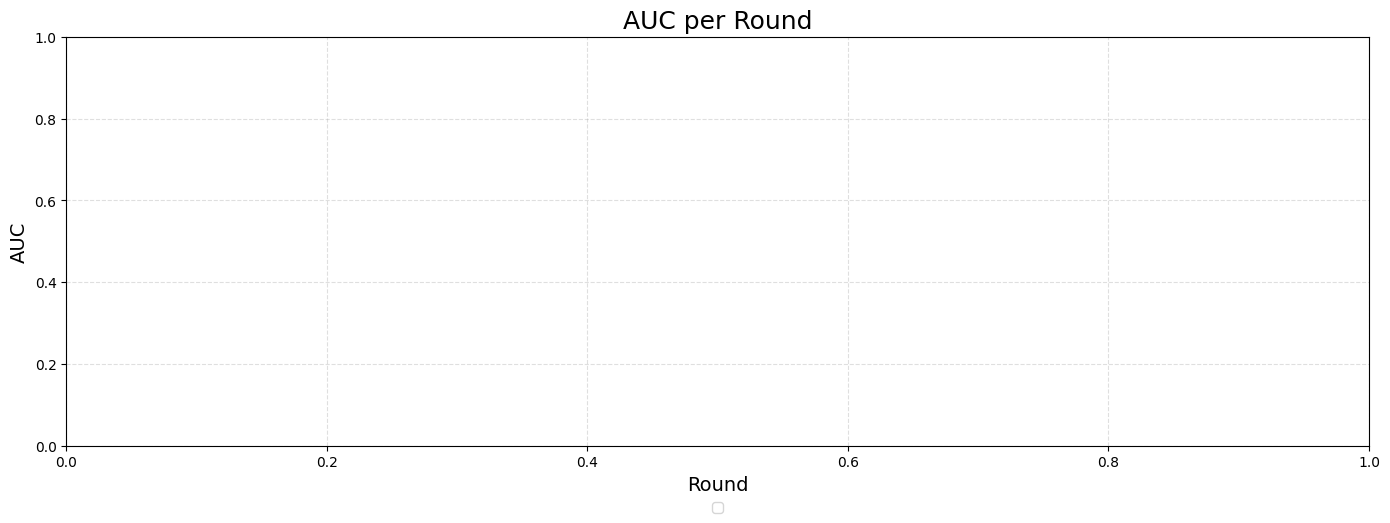

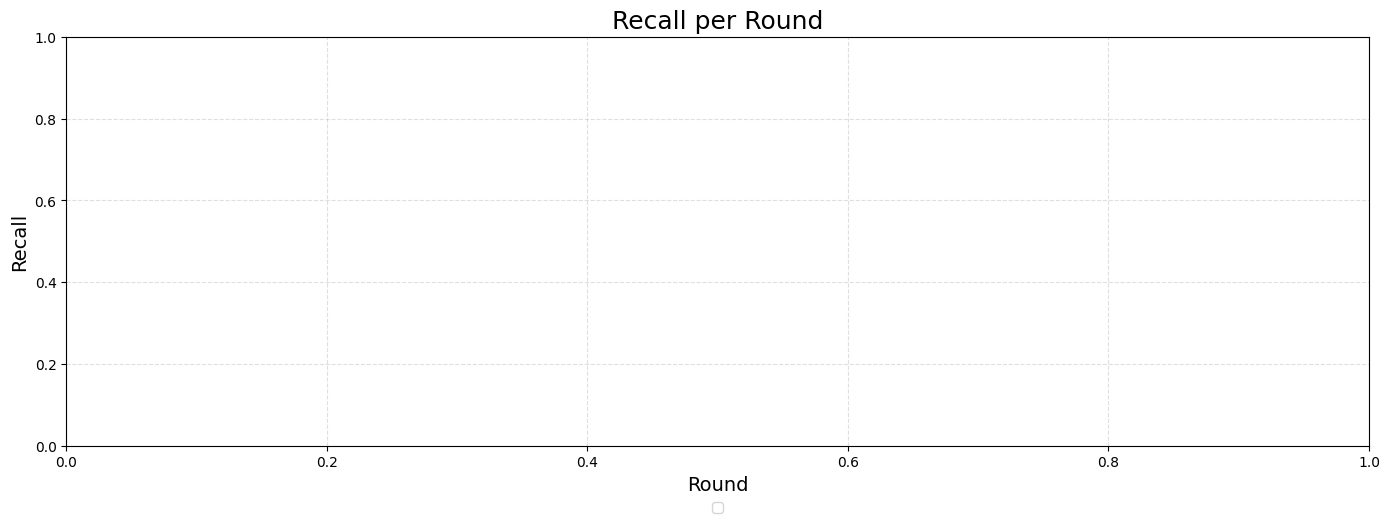

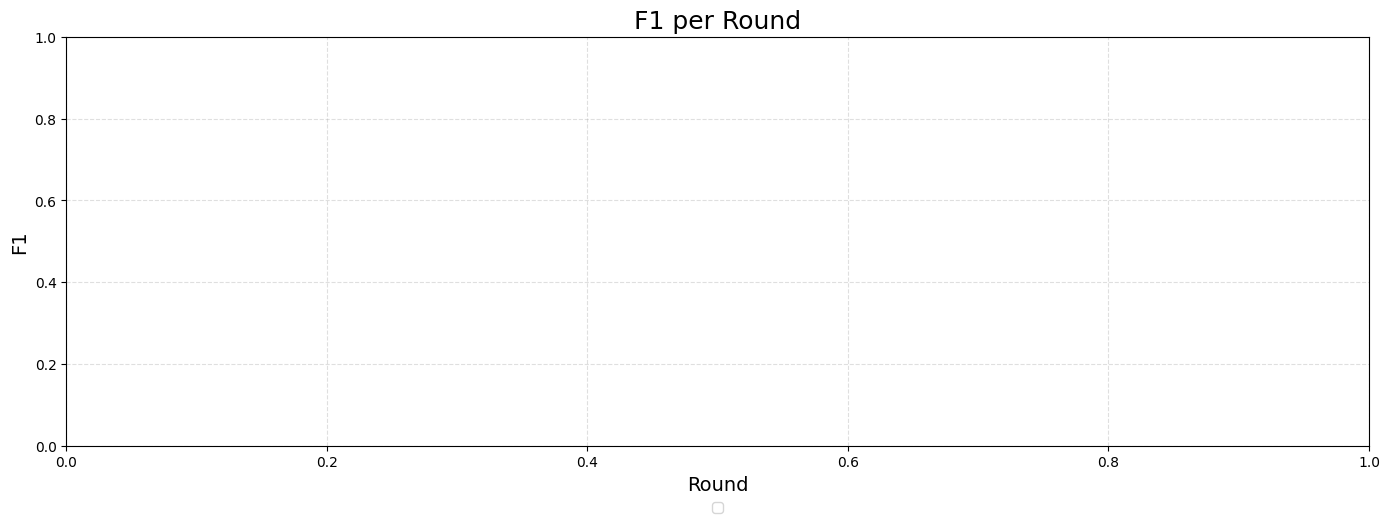

,NAS SL,Testing SL,Model,F1,AUC,Recall,Precision,threshold,Round


,NAS SL,Testing SL,Model,F1,AUC,Recall,Precision,Threshold
0,S6,6,TimesNet_Unfrozen,0.6575,0.8328,0.6056,0.719,0.36



📊 FINAL GENERALIZATION GAP RESULTS - ALL MODELS


,Model,Train_F1,Val_F1,Test_F1,Train_vs_Val_Gap,Train_vs_Test_Gap,Val_vs_Test_Gap,Threshold
0,TimesNet_Unfrozen,0.674,0.6874,0.6575,-0.0134,0.0165,0.0299,0.36



🎯 SECOND OPERATING POINT (F2, validation-calibrated)


,Model,Threshold_F1,Threshold_F2,Val_F2,Test_F1_at_F2,Test_Recall_at_F2,Test_Precision_at_F2
0,TimesNet_Unfrozen,0.36,0.2,0.6768,0.6816,0.6947,0.6691


In [29]:
plot_progressive_results(
    results_table,
    metrics=("AUC", "Recall", "F1"),
    round_col="Round"
)
summary = summary.sort_values(
        by=[ "Model"],
        ascending=True
    ).reset_index(drop=True)

display(summary)

print("\n" + "="*70)
print("📊 FINAL GENERALIZATION GAP RESULTS - ALL MODELS")
print("="*70)

display(gap_table.sort_values("Model").reset_index(drop=True))
print("\n" + "="*70)
print("🎯 SECOND OPERATING POINT (F2, validation-calibrated)")
print("="*70)

display(op2_table.sort_values("Model").reset_index(drop=True))
#op2_table.to_csv(os.path.join(RESULTS_OUT, f"op2_Base{Base_SL}_{max_seq_len}.csv"), index=False)


#### Gap

#FLOP

## FLOP profiling for neural models

In [30]:
flop_results = {}
INPUT_DIM_TIMESNET = 13
INPUT_DIM_SEQ = trans_X_train.shape[2]
NUM_CLASSES = 2
prof_device = torch.device("cpu")
PROFILE_SL = max_seq_len
timesnet_root_path = data_path
timesnet_data_name = "FraudDataset"
def flopcounter_flops(model, inputs):
    model = model.to(prof_device).eval()
    inputs = tuple(x.to(prof_device) if isinstance(x, torch.Tensor) else x for x in inputs)
    model(*inputs)
    with FlopCounterMode(display=False) as fc:
        model(*inputs)
    return fc.get_total_flops()


### Profile TimesNet

In [31]:

L = PROFILE_SL
cfg = Namespace(
    task_name='classification',
    seq_len=L, label_len=48, pred_len=0,
    e_layers=timesnet_parameters["e_layers"],
    d_model=timesnet_parameters["d_model"],
    d_ff=timesnet_parameters["d_ff"],
    top_k=timesnet_parameters["top_k"],
    num_kernels=timesnet_parameters["num_kernels"],
    enc_in=INPUT_DIM_TIMESNET, c_out=INPUT_DIM_TIMESNET,
    embed='timeF', freq='h',
    dropout=timesnet_parameters["dropout"],
    num_class=NUM_CLASSES,
    n_heads=8, d_layers=1, factor=1, distil=True, activation='gelu',
)

model = TimesNetModel(cfg).to(prof_device).eval()

args = Namespace(
    task_name='classification',
    root_path=timesnet_root_path,
    data_path=timesnet_data_name,
    data='UEA',
    seq_len=L, label_len=48, pred_len=0,
    features='M', target='OT', embed='timeF', freq='h',
    batch_size=1, num_workers=0, seasonal_patterns='Monthly',
    augmentation_ratio=0,
)

_, loader = data_provider(args, flag='TEST')
x, _, padding_mask = next(iter(loader))
x, padding_mask = x.to(prof_device), padding_mask.to(prof_device)

model(x, padding_mask, None, None)
with FlopCounterMode(display=False) as fc:
    model(x, padding_mask, None, None)

flop_results[("TimesNet", L)] = fc.get_total_flops()

##  Latency

In [32]:


# ============================================================
# NN CPU latency (for fair comparison with tree models)
# ============================================================
@torch.no_grad()
def measure_nn_latency_cpu(model, inputs_fn, n_repeat=100, n_warmup=10):
    model.eval().to("cpu")
    for _ in range(n_warmup):
        model(*inputs_fn())
    times = []
    for _ in range(n_repeat):
        t0 = time.perf_counter()
        model(*inputs_fn())
        times.append(time.perf_counter() - t0)
    return round(np.median(times) * 1e6, 2)  # μs


nn_latency = {}
L = PROFILE_SL

# TimesNet
cfg = Namespace(
    task_name='classification',
    seq_len=L, label_len=48, pred_len=0,
    e_layers=timesnet_parameters["e_layers"],
    d_model=timesnet_parameters["d_model"],
    d_ff=timesnet_parameters["d_ff"],
    top_k=timesnet_parameters["top_k"],
    num_kernels=timesnet_parameters["num_kernels"],
    enc_in=INPUT_DIM_TIMESNET, c_out=INPUT_DIM_TIMESNET,
    embed='timeF', freq='h',
    dropout=timesnet_parameters["dropout"],
    num_class=NUM_CLASSES,
    n_heads=8, d_layers=1, factor=1, distil=True, activation='gelu',
)
m = TimesNetModel(cfg).to(prof_device).eval()

args = Namespace(
    task_name='classification',
    root_path=timesnet_root_path,
    data_path=timesnet_data_name,
    data='UEA',
    seq_len=L, label_len=48, pred_len=0,
    features='M', target='OT', embed='timeF', freq='h',
    batch_size=1, num_workers=0, seasonal_patterns='Monthly',
    augmentation_ratio=0,
)


_, loader = data_provider(args, flag='TEST')
x, _, pm = next(iter(loader))

nn_latency[("TimesNet", L)] = measure_nn_latency_cpu(
    m,
    lambda x=x, pm=pm: (x, pm, None, None),
)

## Summary

In [33]:
rows = []

# Neural models — keyed by (model, SL)
for (m, sl), fl in flop_results.items():
    rows.append({"Model": m, "SL": sl,
                 "FLOPs": fl, "MFLOPs": round(fl/1e6, 4),
                 "Comparisons": "—",
                 "Latency (μs)": nn_latency.get((m, sl), "—")})



df_combined = pd.DataFrame(rows).sort_values(["Model", "SL"]).reset_index(drop=True)
# Align cost table names to match summary names
name_map = {
    "TimesNet": "TimesNet_Unfrozen",
    "Transformer": "TransformerFraud",
}
df_combined["Model"] = df_combined["Model"].replace(name_map)

# Add a second row for PartialUnfreeze (same cost as Unfrozen — same architecture)
tn_row = df_combined[df_combined["Model"] == "TimesNet_Unfrozen"].copy()
tn_row["Model"] = "TimesNet_PartialUnfreeze"
df_combined = pd.concat([df_combined, tn_row], ignore_index=True)

final_report = pd.merge( summary,df_combined, on='Model', how='inner')
final_report = pd.merge( final_report,gap_table, on='Model', how='inner')
#final_report.to_csv(os.path.join(RESULTS_OUT, f"final_report_Base{Base_SL}_{max_seq_len}.csv"), index=False)

display(final_report)

# df_combined.to_csv("compute_cost_all_models.csv", index=False)
# display(df_combined)

,NAS SL,Testing SL,Model,F1,AUC,Recall,Precision,Threshold_x,SL,FLOPs,MFLOPs,Comparisons,Latency (μs),Train_F1,Val_F1,Test_F1,Train_vs_Val_Gap,Train_vs_Test_Gap,Val_vs_Test_Gap,Threshold_y
0,S6,6,TimesNet_Unfrozen,0.6575,0.8328,0.6056,0.719,0.36,6,17218944,17.2189,—,11916.9,0.674,0.6874,0.6575,-0.0134,0.0165,0.0299,0.36


# New Section

## Graph Summary

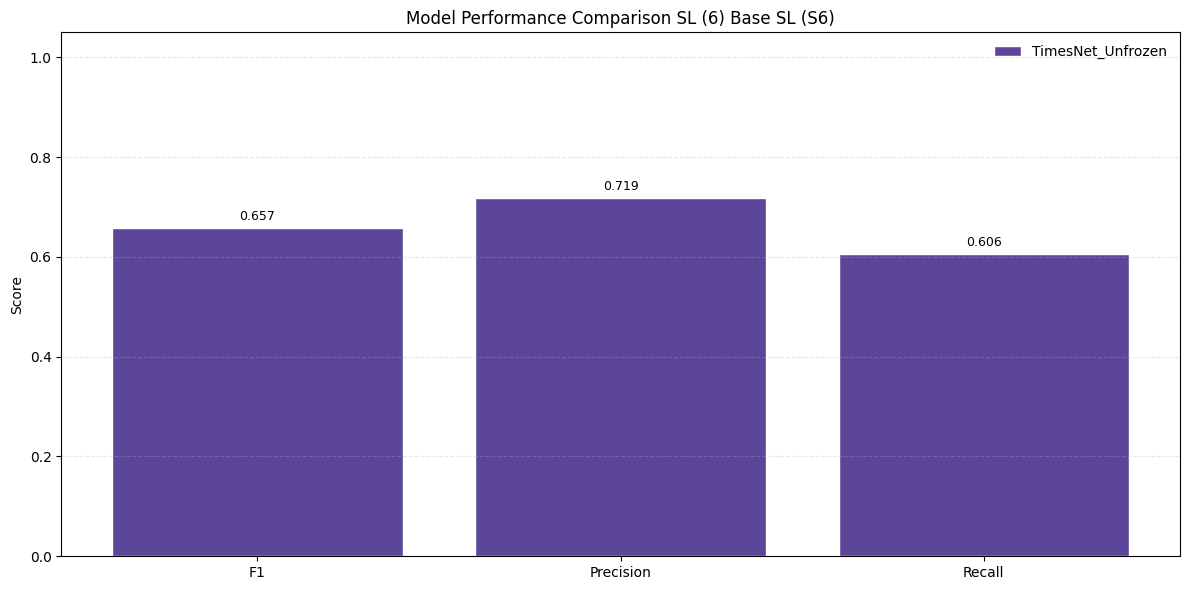

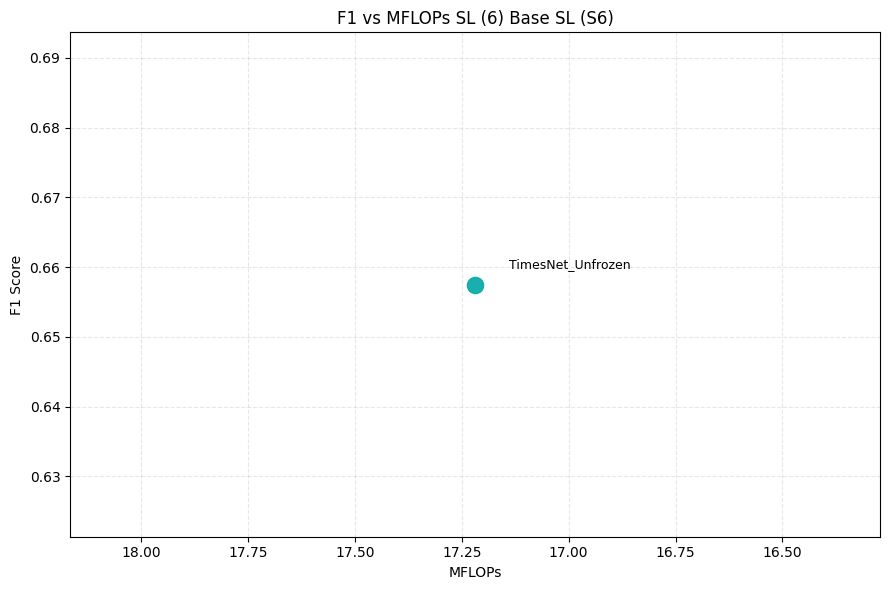

In [34]:

plt.style.use("default")

# =========================
# 1) Bar chart: F1 / Precision / Recall
# =========================
metrics_df = final_report[["Model", "F1", "Precision", "Recall"]].copy()
metrics_df = metrics_df.sort_values(by="F1", ascending=False).reset_index(drop=True)
metrics = ["F1", "Precision", "Recall"]
models = metrics_df["Model"].values

x = np.arange(len(metrics))
width = 0.8 / len(models)  # dynamic width based on number of models

plt.figure(figsize=(12, 6))

bars_all = []
colors = ["#5C4699", "#2E6BB3", "#00ADEE", "#1EBBAD", "#4DB848", "#A1D82E"]
#colors = ["#2D527C", "#3E8E91", "#7BB3B5", "#A8D5BA", "#F2E8CF", "#E76F51"]
#colors = ["#264653", "#2A9D8F", "#E9C46A", "#F4A261", "#E76F51", "#8D99AE"]
for i, model in enumerate(models):
    values = metrics_df.loc[metrics_df["Model"] == model, metrics].values.flatten()

    bars = plt.bar(
        x + (i - len(models)/2) * width + width/2,
        values,
        width,
        label=model,
        color=colors[i],   # 👈 correct
        edgecolor="white",

    )
    bars_all.append(bars)

# X-axis = metrics
plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title(f"Model Performance Comparison SL ({max_seq_len}) Base SL ({Base_SL})")
plt.ylim(0, 1.05)
plt.legend(frameon=False)
plt.grid(axis="y", linestyle="--", alpha=0.3)

# Labels on bars
for bars in bars_all:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.show()
# =========================
# 2) F1 vs MFLOPs
#    Only models with real MFLOPs
# =========================
cost_df = final_report.copy()
cost_df["MFLOPs"] = pd.to_numeric(cost_df["MFLOPs"], errors="coerce")

# Do NOT fill XGB/RF. Drop models without real MFLOPs.
cost_df = cost_df.dropna(subset=["MFLOPs", "F1"]).copy()
cost_df = cost_df.sort_values(by="MFLOPs", ascending=True)

plt.figure(figsize=(9, 6))

plt.scatter(
    cost_df["MFLOPs"],
    cost_df["F1"],
    s=140,
    color="#00A6A6",   # purple
    #edgecolor="black",
    linewidth=0.8,
    alpha=0.9
)

for _, row in cost_df.iterrows():
    x = row["MFLOPs"]
    y = row["F1"]

    # Shift label LEFT (since axis is inverted)
    plt.text(
        x - 0.08,   # move left
        y + 0.002,  # slight vertical offset
        row["Model"],
        fontsize=9,
        ha="left",   # align text properly
        va="bottom"
    )

plt.xlabel("MFLOPs")
plt.ylabel("F1 Score")
plt.title(f"F1 vs MFLOPs SL ({max_seq_len}) Base SL ({Base_SL})")
plt.grid(True, linestyle="--", alpha=0.3)
plt.gca().invert_xaxis()  # makes "better" direction visually left
plt.tight_layout()
plt.show()

#freeze

In [35]:
%pip freeze > "{project_path}requirement/freez/NASEnhancedPretraindMLModleAdvance-lock.txt"

In [36]:
end = time.time()
elapsed = end - start_time

hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)

print(f"Total Time = {hours}h {minutes}m {seconds}s")

Total Time = 0h 8m 53s


In [37]:
!grep -n "seed" /content/drive/MyDrive/Sem-6/coding/github/fraud_detection/Time-Series-Library/run.py

15:    fix_seed = 2021
16:    random.seed(fix_seed)
17:    torch.manual_seed(fix_seed)
18:    np.random.seed(fix_seed)
118:    parser.add_argument('--seed', type=int, default=2021, help="Randomization seed")
163:    random.seed(args.seed)
164:    torch.manual_seed(args.seed)
165:    np.random.seed(args.seed)
